IMPORT LIBRARIES

In [109]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# SMOTE
from imblearn.over_sampling import SMOTE

LOAD DATASET

In [110]:
df = pd.read_csv("Final_retention_augmented_dataset.csv")

print(df.shape)
df.head()

(4424, 50)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,absences,famsup,failures,freetime,goout,raisedhands,VisITedResources,AnnouncementsView,Discussion,StudentAbsenceDays
0,1,17,5,171,1,1,122.0,1,19,12,...,2,yes,0,4,3,29,97,19,8,Above-7
1,1,15,1,9254,1,1,160.0,1,1,3,...,2,no,0,3,3,77,18,65,13,Under-7
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,no,2,3,3,81,13,98,7,Under-7
3,1,17,2,9773,1,1,122.0,1,38,37,...,18,yes,0,3,3,9,7,74,93,Under-7
4,2,39,1,8014,0,1,100.0,1,37,38,...,10,no,0,3,3,15,98,72,80,Under-7


DATA UNDERSTANDING

In [111]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 50 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [112]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,traveltime,studytime,absences,failures,freetime,goout,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,1.419078,2.042043,6.117089,0.324141,3.243445,3.089964,47.962929,54.876582,38.852170,44.354430
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.662457,0.854849,8.329216,0.731572,0.988152,1.108228,30.737325,33.110400,26.605921,27.363598
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,1.000000,1.000000,0.000000,0.000000,3.000000,2.000000,19.000000,20.000000,15.000000,20.000000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,1.000000,2.000000,4.000000,0.000000,3.000000,3.000000,50.000000,65.000000,35.000000,40.000000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,2.000000,2.000000,8.000000,0.000000,4.000000,4.000000,78.000000,84.000000,59.000000,70.000000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,4.000000,4.000000,75.000000,3.000000,5.000000,5.000000,100.000000,99.000000,98.000000,99.000000


MISSING VALUES HANDLING

In [113]:
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance\t,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


Fill missing values

In [114]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Numerical → mean
imputer_num = SimpleImputer(strategy='mean')
df[num_cols] = imputer_num.fit_transform(df[num_cols])

# Categorical → most frequent
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

DUPLICATE REMOVAL

In [115]:
df.drop_duplicates(inplace=True)

FEATURE VISUALIZATION

Target Distribution

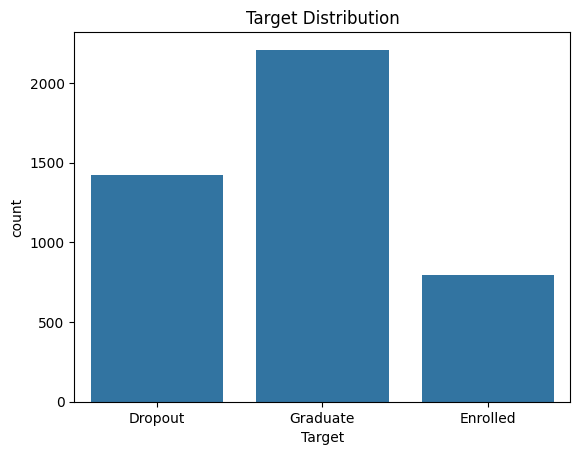

In [116]:
sns.countplot(x='Target', data=df)
plt.title("Target Distribution")
plt.show()

The dataset shows a class imbalance among the target categories. The majority of students belong to the "Graduate" class, followed by "Dropout", while the "Enrolled" category has the lowest representation.

This imbalance indicates that the model may become biased toward predicting the majority class. Therefore, techniques such as SMOTE are necessary to balance the dataset and improve model performance, especially for minority classes like "Enrolled".

Numerical Features Distribution

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


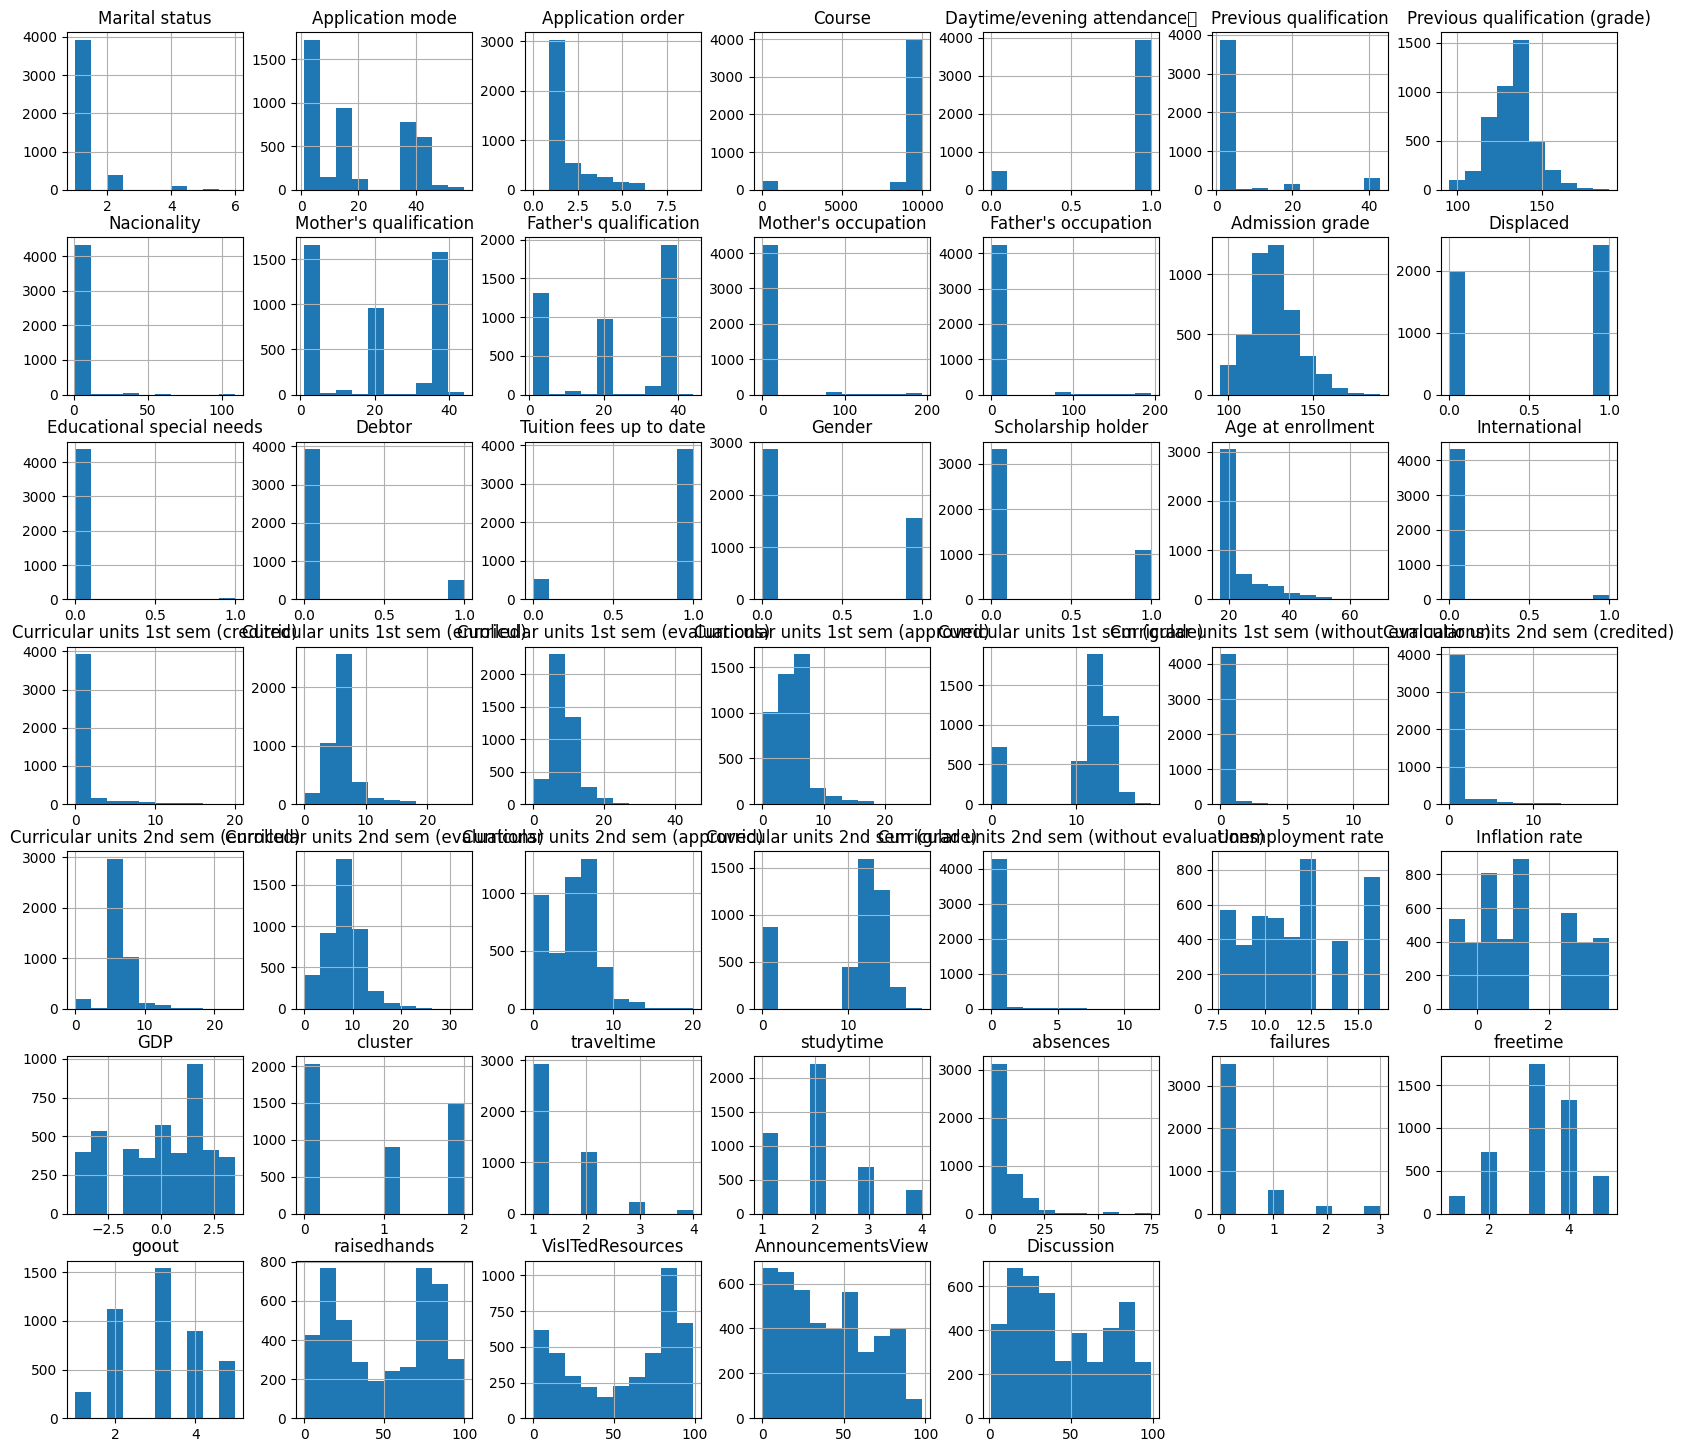

In [117]:
df.hist(figsize=(20,18))
plt.show()

Boxplot (Outliers Detection)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


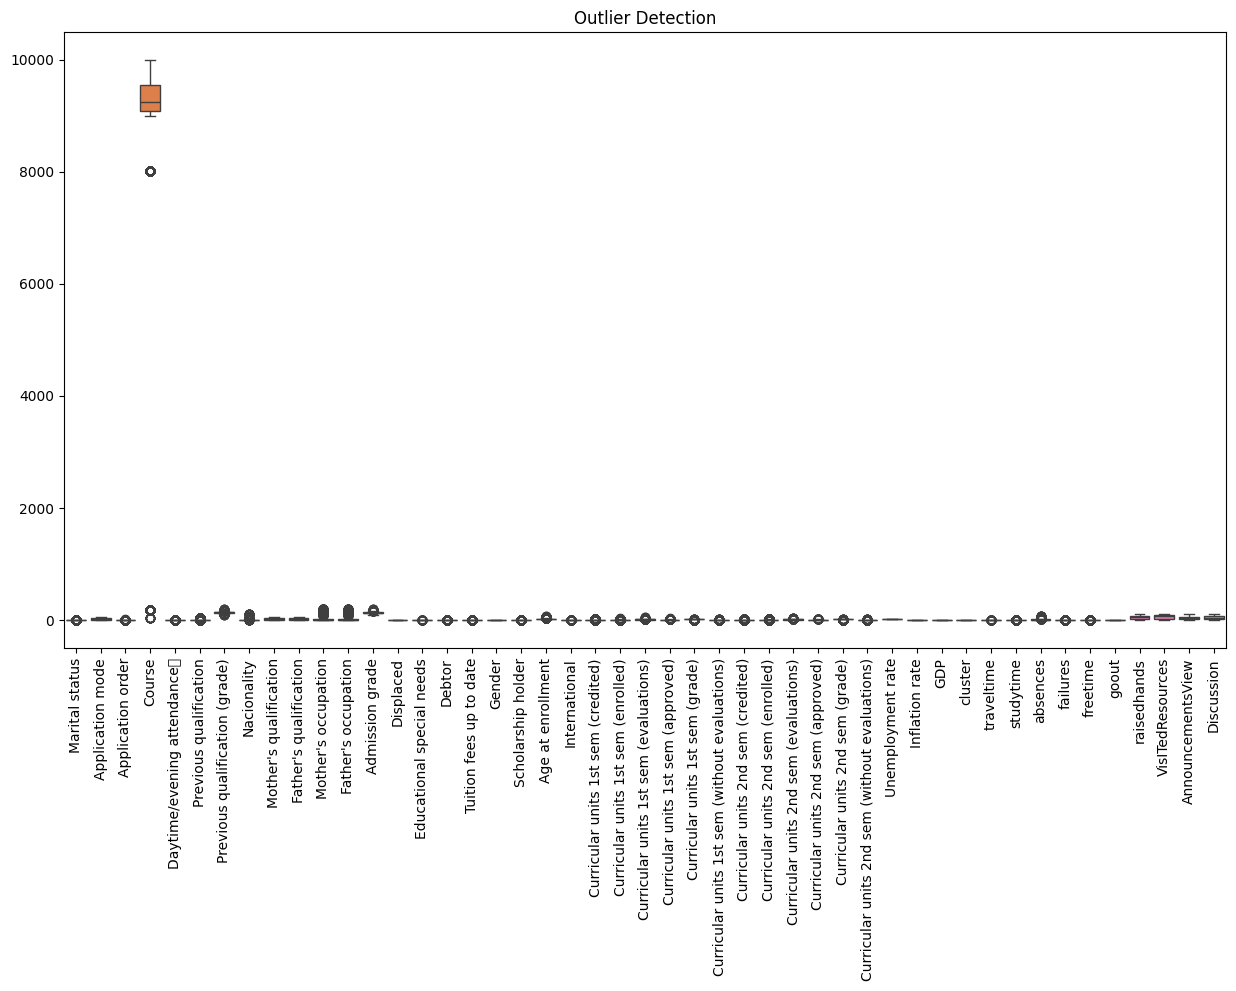

In [118]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

- The **Course feature shows extremely high values** (around 8000–10000), which dominate the scale of the plot. This indicates that the feature is encoded as categorical IDs rather than meaningful numerical values.

- Due to this large scale difference, most other features appear compressed near zero, making it difficult to visually interpret their distributions.

- Several features such as:
  - Absences
  - Raised hands
  - Visited resources  
  show visible outliers, indicating variability in student behavior.

- Academic features (grades, approvals) appear more consistently distributed with fewer extreme outliers.

Correlation Heatmap

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


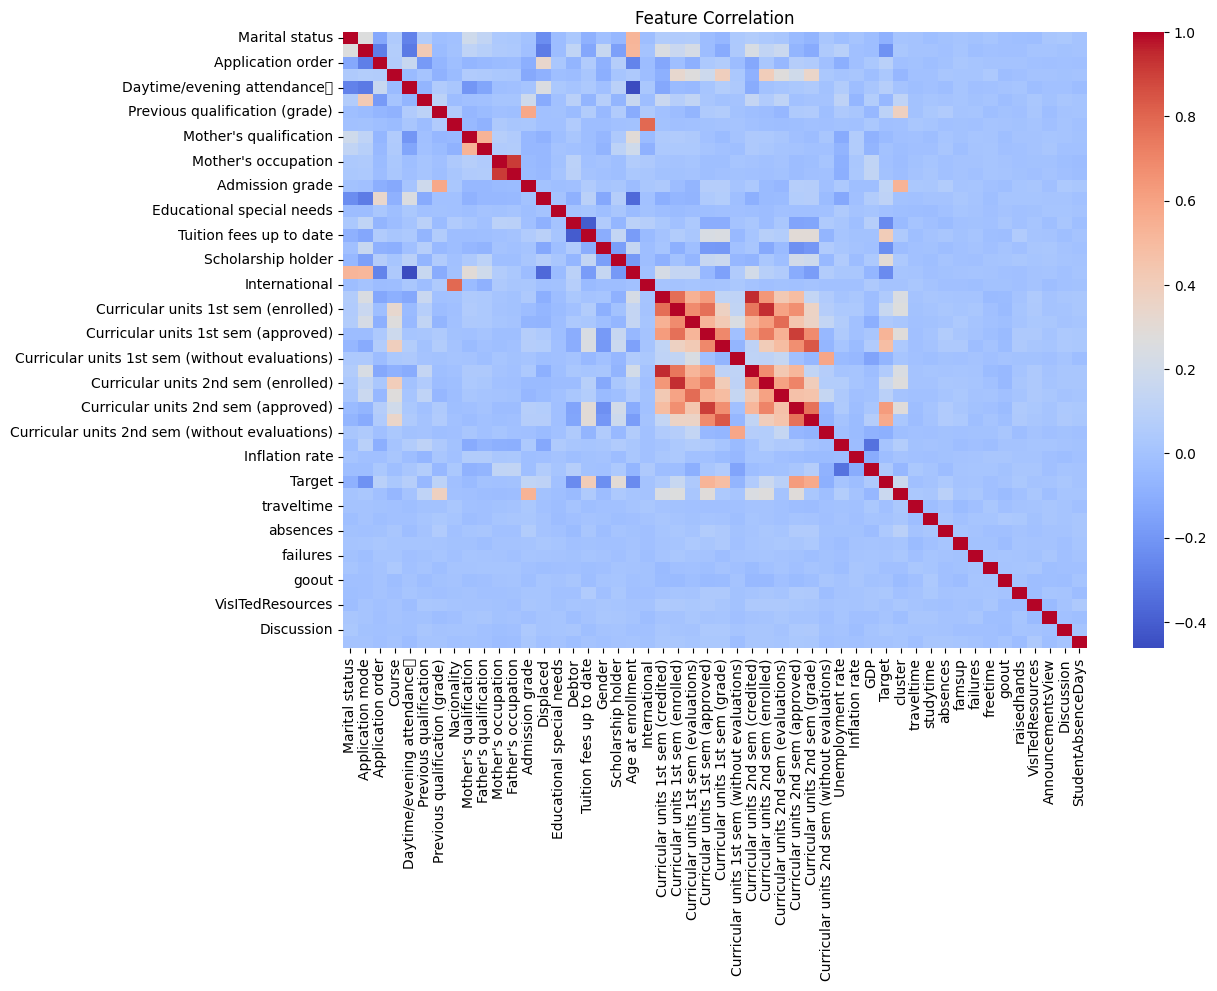

In [119]:
from sklearn.preprocessing import LabelEncoder

# Make a copy of the dataframe to avoid modifying the original df for subsequent operations if needed
df_encoded = df.copy()

# Identify categorical columns that are still objects
cat_cols_for_encoding = df_encoded.select_dtypes(include=['object']).columns

# Apply Label Encoding to each categorical column
for col in cat_cols_for_encoding:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])

plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

Red = strong positive
Blue = negative

- The heatmap shows the pairwise correlation between all features in the dataset.

- A strong positive correlation is observed among academic performance features, particularly:
  - Curricular units (enrolled, approved, grade) in both semesters
  - These features are highly interrelated and represent student academic success.

- The strongest correlations are concentrated in the academic block, indicating that:
  - Students who perform well in one semester tend to perform well in the next.
  - Approval rates and grades are closely linked.

- Most demographic and socio-economic features (e.g., gender, nationality, parental education) show weak or negligible correlation with other features.

- Behavioral and engagement features (e.g., absences, raised hands, visited resources) show moderate but not strong correlations, indicating independent influence on student outcomes.

- The target variable shows some correlation with:
  - Academic performance features
  - Financial features such as tuition fees status
  This suggests that both academic and financial factors influence dropout.

- Very few strong negative correlations are observed, indicating that most features do not have inverse relationships.

- The presence of highly correlated academic features suggests potential redundancy, and dimensionality reduction or feature selection may be beneficial.

- Strong correlations exist among academic performance features.
- Academic features are the most important predictors.
- Behavioral and engagement features show moderate influence.
- Demographic features have low correlation.
- Some redundancy exists among features.

Important Feature vs Target

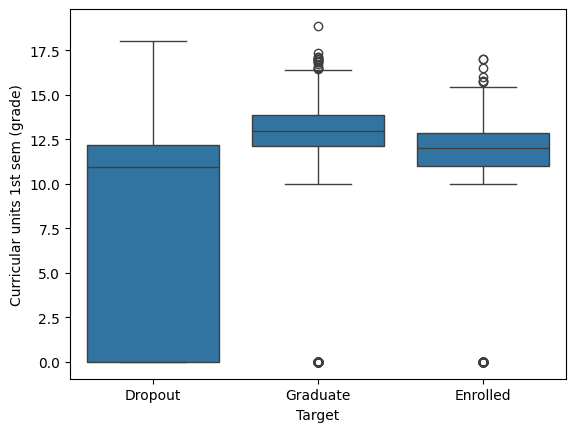

In [120]:
sns.boxplot(x='Target', y='Curricular units 1st sem (grade)', data=df)
plt.show()

- Graduate students have higher grades.
- Dropout students have lower and more variable grades.
- Academic performance strongly influences retention.

ENCODING CATEGORICAL VARIABLES

In [121]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

FEATURE SCALING

In [122]:
scaler = StandardScaler()

X = df.drop('Target', axis=1)
y = df['Target']

X_scaled = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled, columns=X.columns)

FEATURE SELECTION

METHOD 1: RANDOM FOREST FEATURE IMPORTANCE

In [123]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

rf_importance.head(25)

,Feature,Importance
30,Curricular units 2nd sem (approved),0.115147
31,Curricular units 2nd sem (grade),0.091768
24,Curricular units 1st sem (approved),0.084338
25,Curricular units 1st sem (grade),0.060224
16,Tuition fees up to date,0.042353
29,Curricular units 2nd sem (evaluations),0.033285
19,Age at enrollment,0.028052
12,Admission grade,0.027547
36,cluster,0.026447
45,VisITedResources,0.026341


METHOD 2: RFE (RECURSIVE FEATURE ELIMINATION)

In [124]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

rfe = RFE(model, n_features_to_select=25)
rfe.fit(X, y)

rfe_features = X.columns[rfe.support_]
print(rfe_features)

Index(['Application mode', 'Course', 'Previous qualification (grade)',
       'Father's qualification', 'Mother's occupation', 'Father's occupation',
       'Admission grade', 'Tuition fees up to date', 'Age at enrollment',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)', 'Unemployment rate', 'GDP',
       'cluster', 'absences', 'raisedhands', 'VisITedResources',
       'AnnouncementsView', 'Discussion'],
      dtype='object')


METHOD 3: SELECT KBEST (ANOVA F-SCORE)

In [125]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=25)
selector.fit(X, y)

kbest_features = X.columns[selector.get_support()]
print(kbest_features)

Index(['Marital status', 'Application mode', 'Application order',
       'Daytime/evening attendance\t', 'Previous qualification (grade)',
       'Mother's qualification', 'Admission grade', 'Displaced', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'cluster'],
      dtype='object')


FINAL COMBINATION

In [126]:
from sklearn.feature_selection import mutual_info_classif

# Calculate mutual information scores
mi_scores = mutual_info_classif(X, y)

# Create a DataFrame for mutual information scores
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': mi_scores
}).sort_values(by='Importance', ascending=False)

mi_top = set(mi_df.head(25)['Feature'])
rf_top = set(rf_importance.head(25)['Feature'])
rfe_top = set(rfe_features)

# Intersection (best reliable features)
final_features = list(mi_top & rf_top & rfe_top)

print("Final Selected Features:", final_features)

Final Selected Features: ['Tuition fees up to date', 'Admission grade', 'Age at enrollment', 'AnnouncementsView', 'Course', 'raisedhands', 'Previous qualification (grade)', 'Discussion', "Father's occupation", 'Curricular units 1st sem (enrolled)', 'Application mode', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (enrolled)', 'cluster', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)', "Mother's occupation", 'Curricular units 2nd sem (evaluations)', 'VisITedResources', 'Curricular units 1st sem (evaluations)']


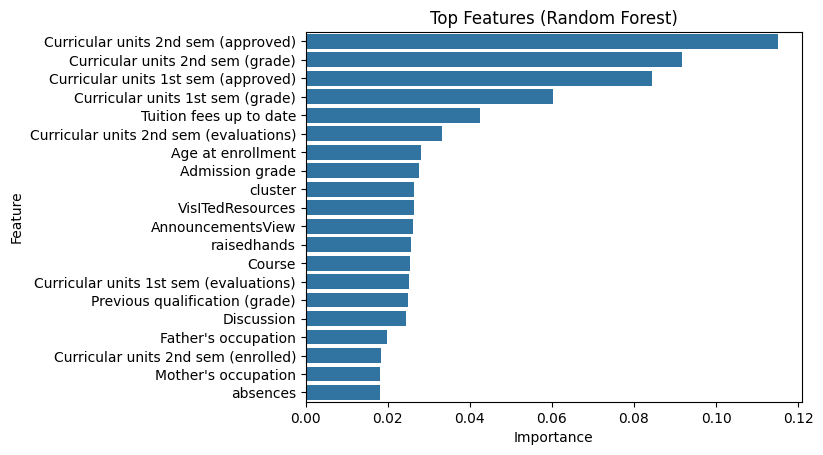

In [127]:
sns.barplot(x='Importance', y='Feature', data=rf_importance.head(20))
plt.title("Top Features (Random Forest)")
plt.show()

In [128]:
final_features_Union = list(mi_top | rf_top | rfe_top)

In [129]:
print(final_features_Union)

['Tuition fees up to date', 'Admission grade', 'Scholarship holder', 'Age at enrollment', 'Course', 'Debtor', 'AnnouncementsView', 'raisedhands', 'Previous qualification (grade)', 'Discussion', 'absences', "Father's occupation", 'Curricular units 1st sem (enrolled)', 'Application mode', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (enrolled)', 'cluster', 'Curricular units 1st sem (grade)', "Father's qualification", 'GDP', 'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)', 'Gender', "Mother's occupation", 'Unemployment rate', 'Previous qualification', 'Curricular units 2nd sem (evaluations)', 'VisITedResources', 'Curricular units 1st sem (evaluations)']


Intersection	High confidence features
Union	More coverage

### Feature Selection Strategy

- Two approaches were considered:
  - Intersection of feature selection methods
  - Union of selected features

- The union approach was chosen to retain a diverse set of features, including academic, behavioral, financial, and engagement factors.

- A refined subset of approximately 23–25 features was selected by removing low-impact features.

- This approach ensures:
  - Better model generalization
  - Inclusion of multi-dimensional student behavior
  - Improved performance in ensemble models

Filter Random Forest importance

In [130]:
# Convert list to set (faster lookup)
final_union_set = set(final_features_Union)

# Filter only selected features
rf_union_importance = rf_importance[rf_importance['Feature'].isin(final_union_set)]

# Sort again (important!)
rf_union_importance = rf_union_importance.sort_values(by='Importance', ascending=False)

Plot graph

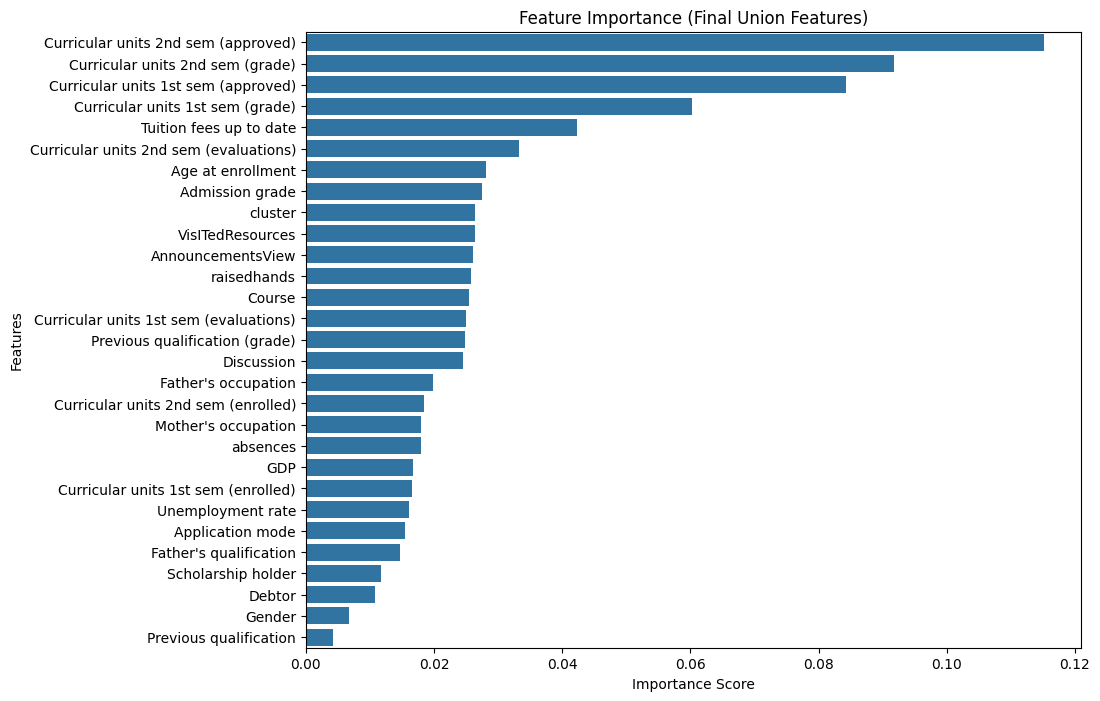

In [131]:
plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=rf_union_importance)

plt.title("Feature Importance (Final Union Features)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

- Academic features are the most important predictors.
- Financial status significantly affects retention.
- Engagement features have moderate impact.
- Demographic features have low importance.

NUMERICAL FEATURES vs TARGET (BOXPLOTS)

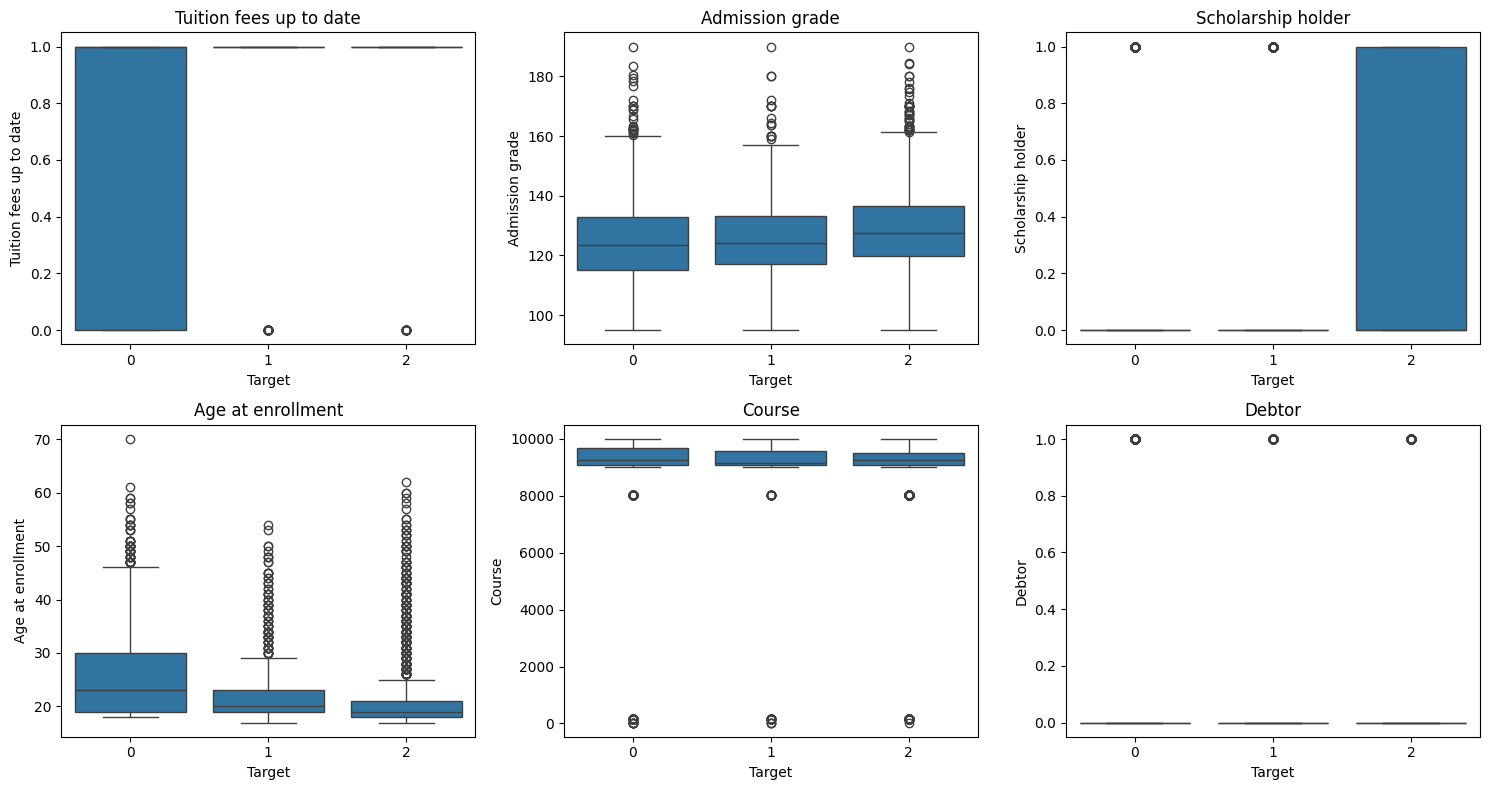

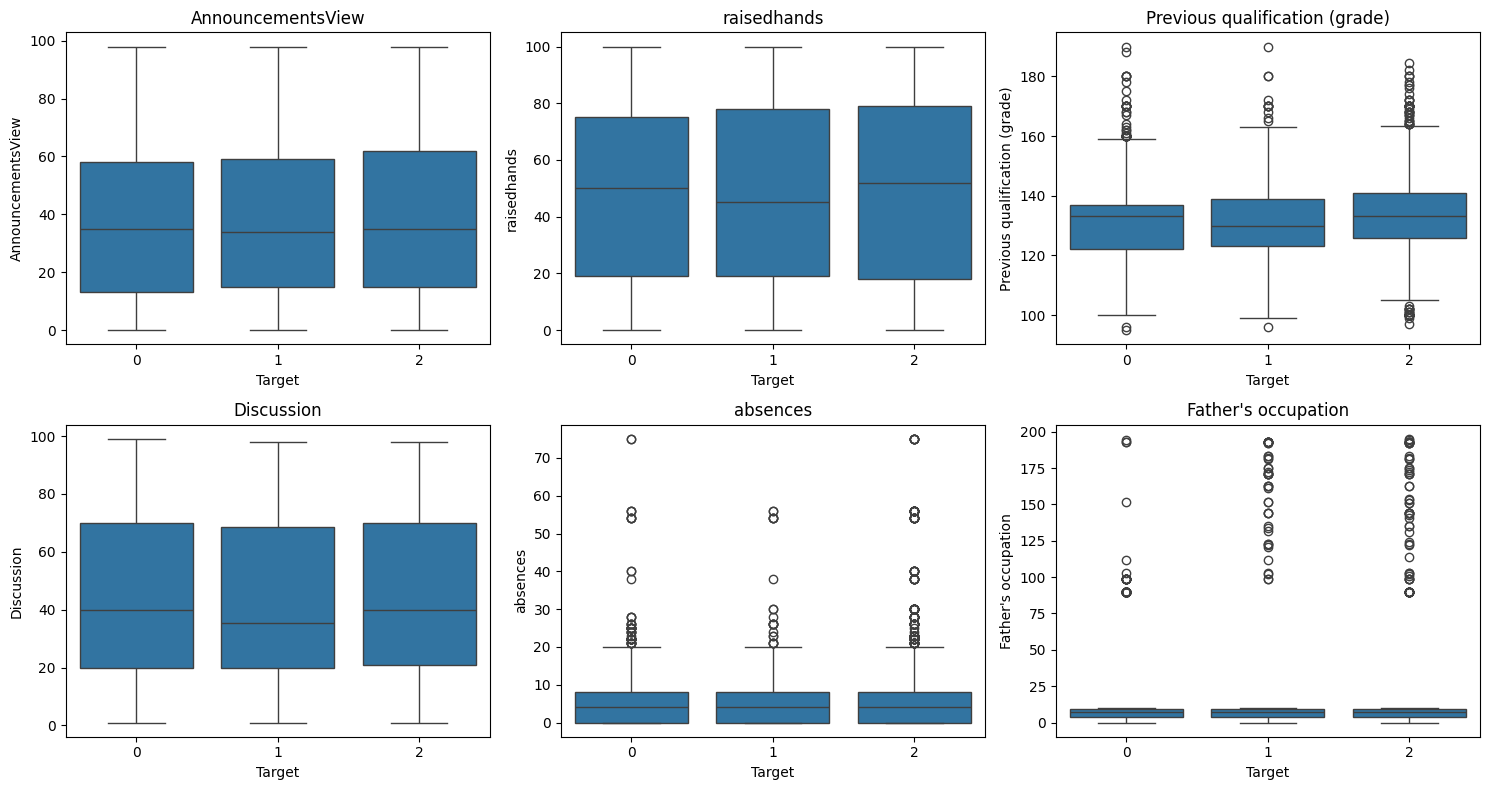

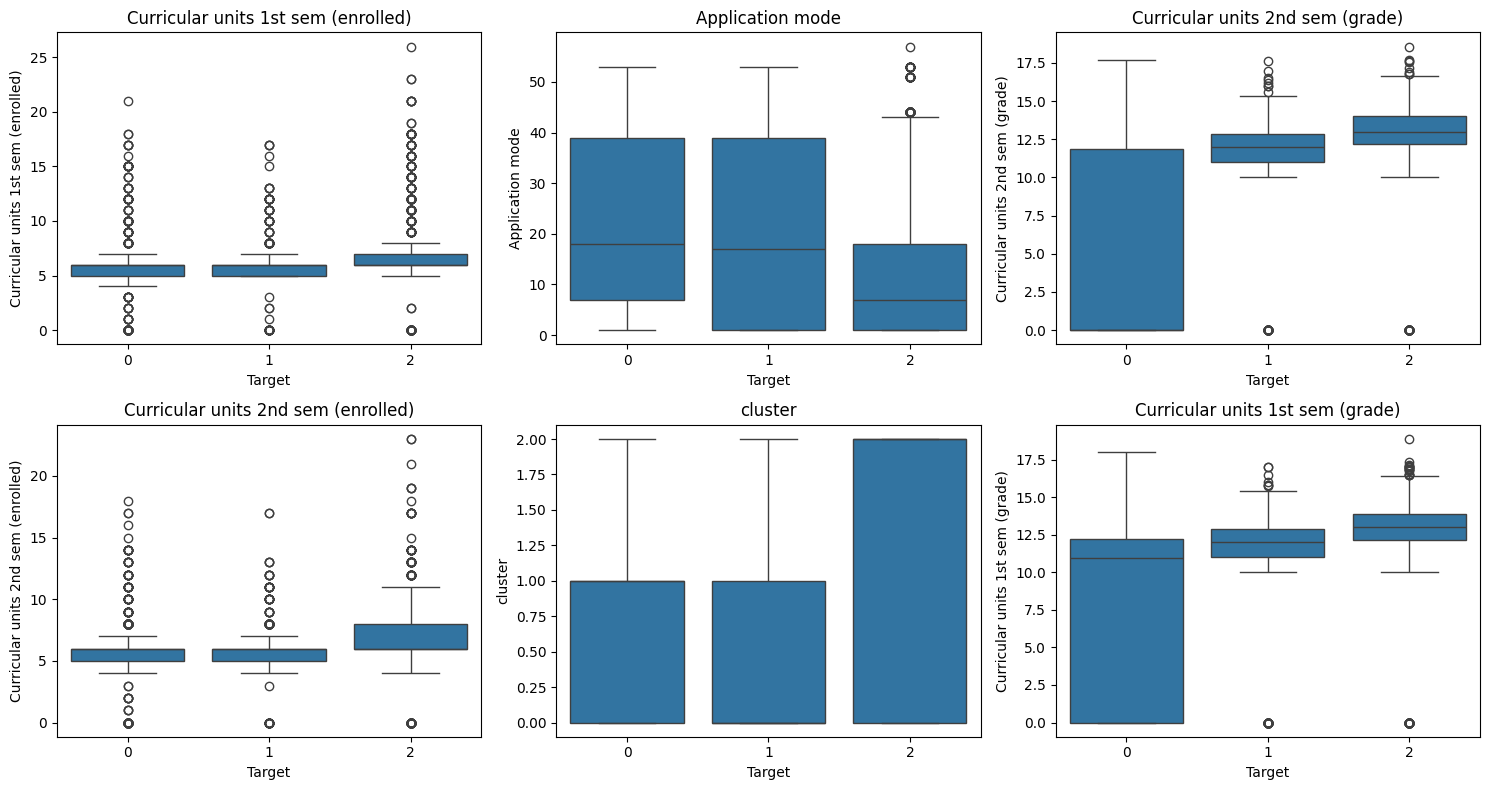

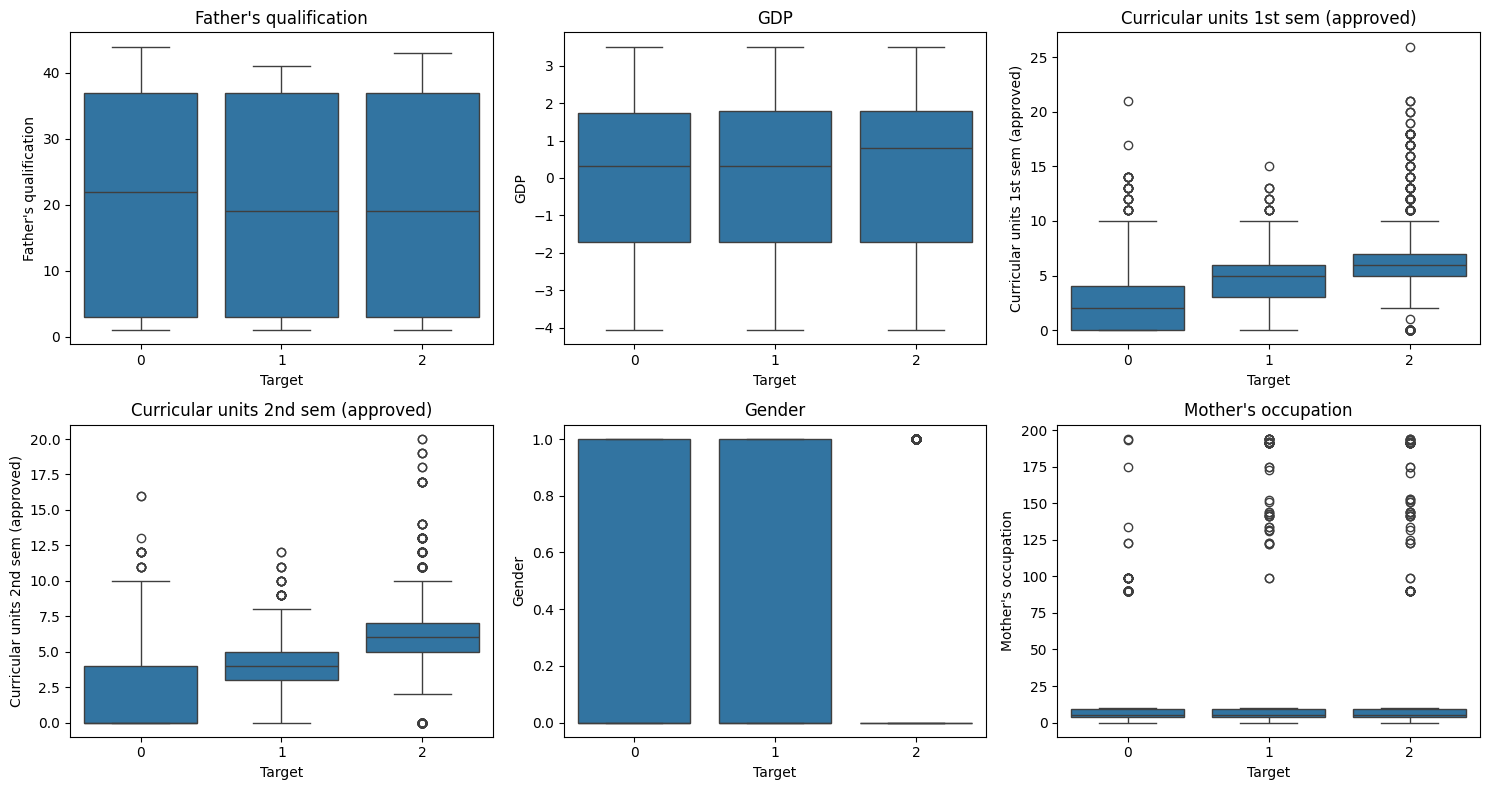

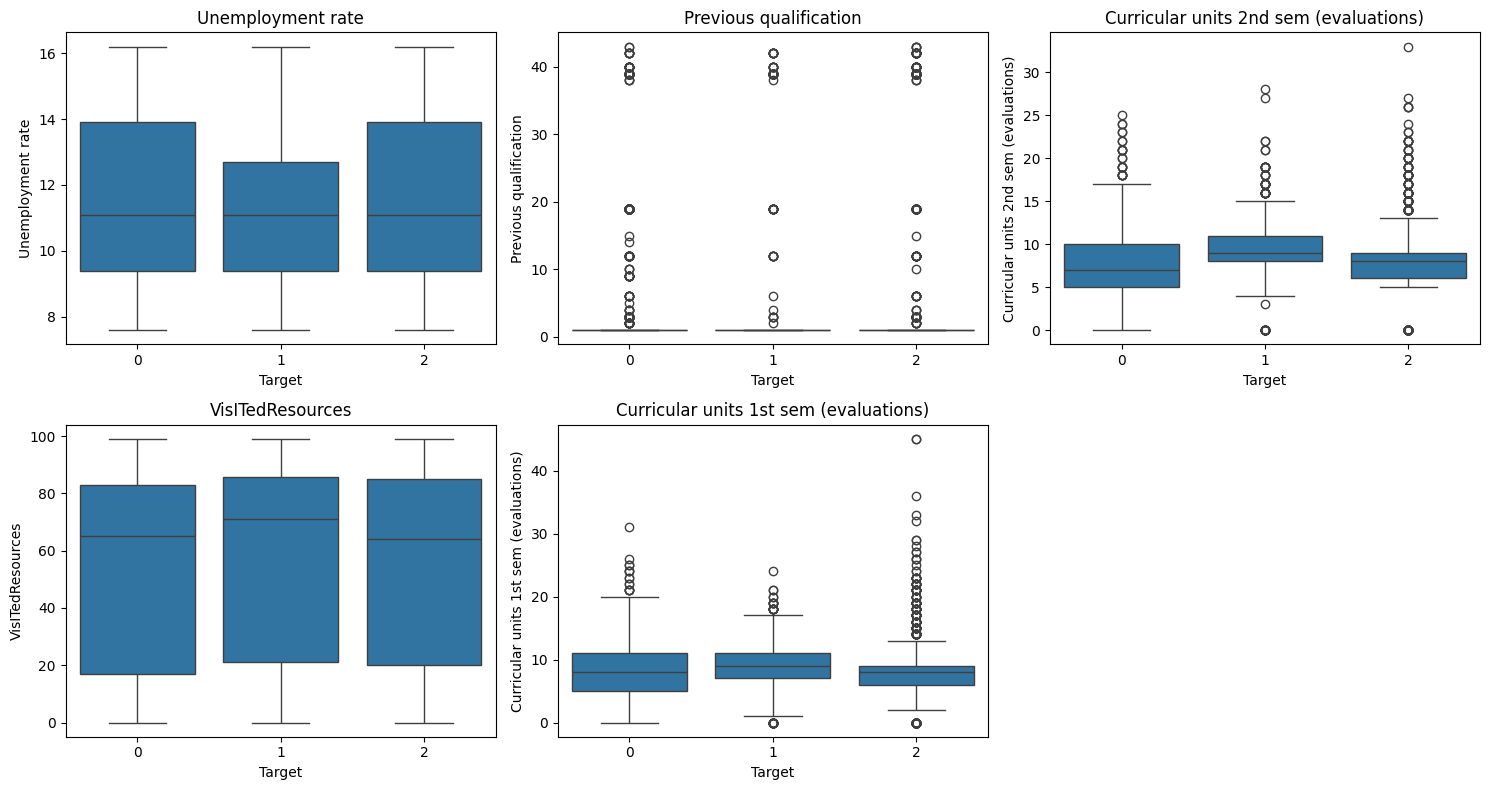

In [132]:
# Separate numerical features from your union list
num_union_features = [col for col in final_features_Union if df[col].dtype != 'object' and col != 'Target']

# Plot in batches (to avoid clutter)
for i in range(0, len(num_union_features), 6):
    subset = num_union_features[i:i+6]

    plt.figure(figsize=(15,8))

    for j, col in enumerate(subset, 1):
        plt.subplot(2, 3, j)
        sns.boxplot(x='Target', y=col, data=df)
        plt.title(col)

    plt.tight_layout()
    plt.show()

CATEGORICAL FEATURES vs TARGET




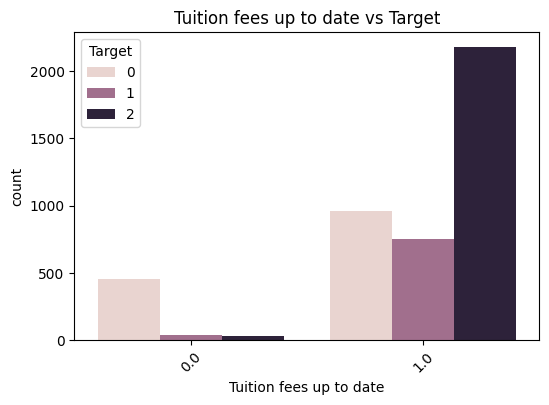

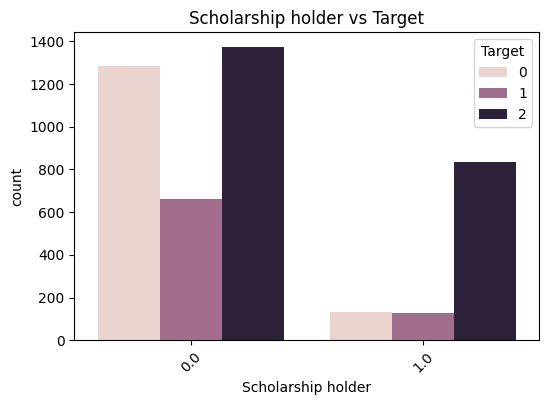

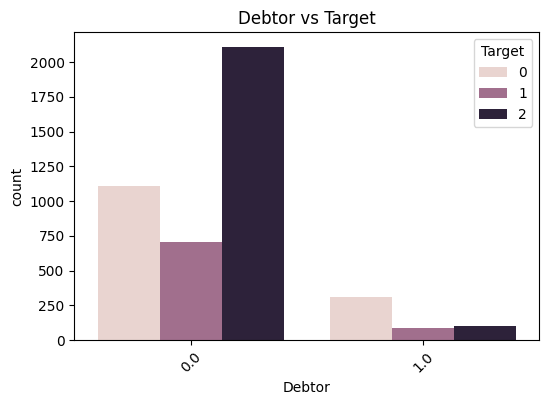

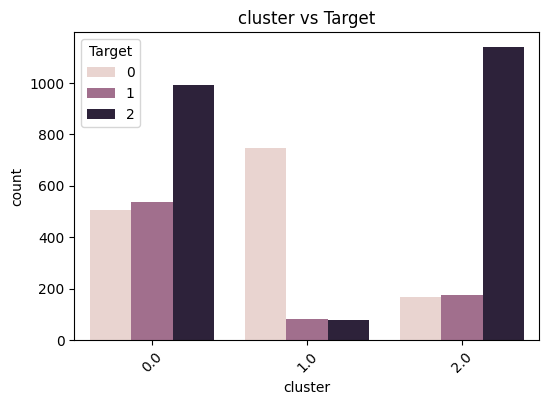

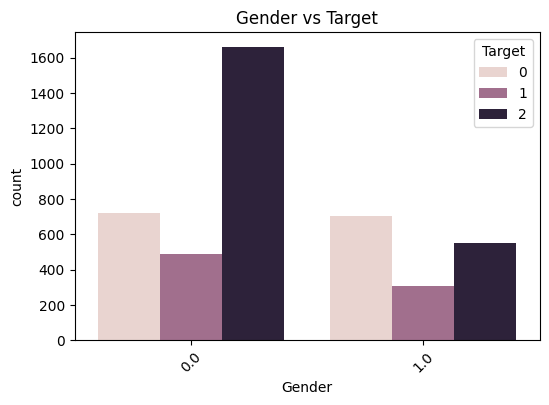

In [133]:
cat_union_features = [col for col in final_features_Union if df[col].dtype == 'object' or df[col].nunique() < 10]

for col in cat_union_features:
    if col != 'Target':
        plt.figure(figsize=(6,4))
        sns.countplot(x=col, hue='Target', data=df)
        plt.title(f"{col} vs Target")
        plt.xticks(rotation=45)
        plt.show()

Mean Feature Values vs Target

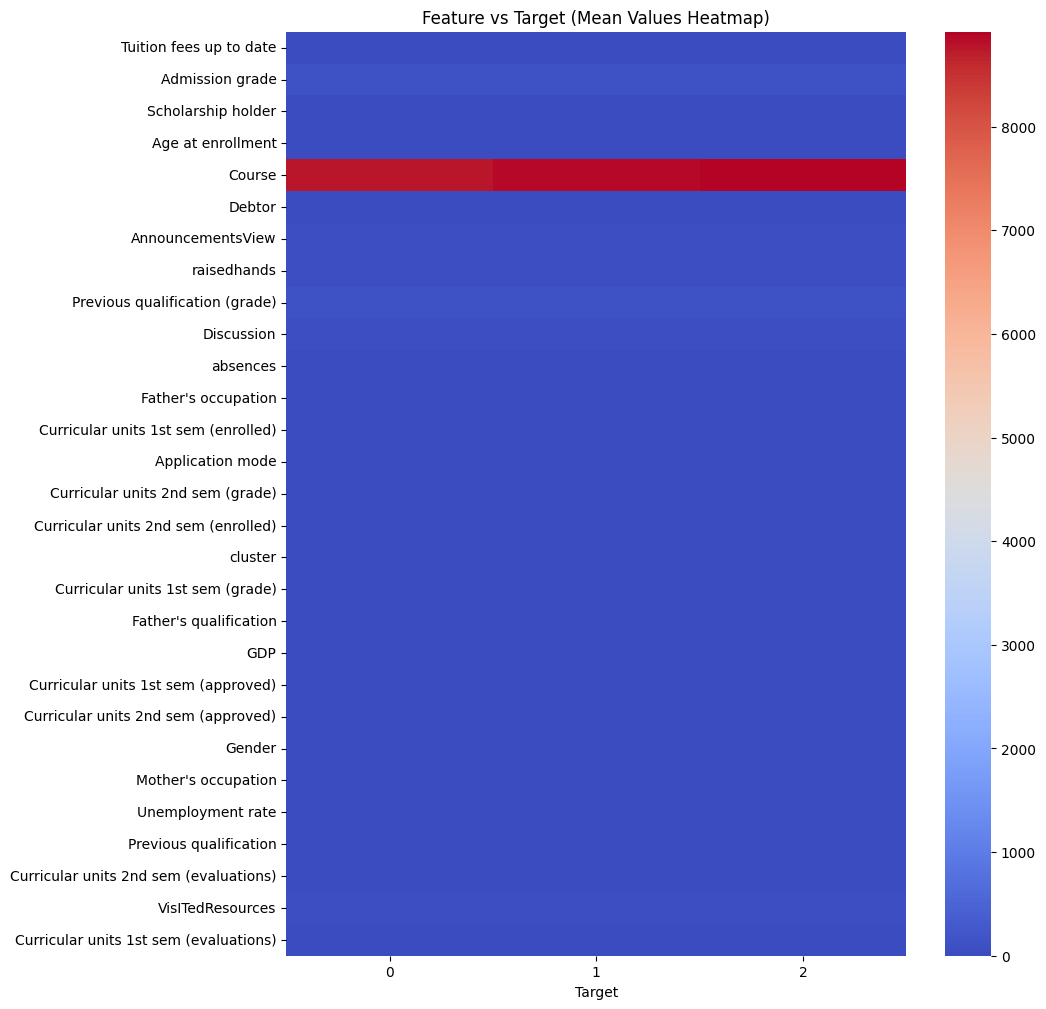

In [134]:
# Group by target and take mean
grouped = df[final_features_Union + ['Target']].groupby('Target').mean().T

# Plot heatmap
plt.figure(figsize=(10,12))
sns.heatmap(grouped, cmap='coolwarm', annot=False)
plt.title("Feature vs Target (Mean Values Heatmap)")
plt.show()

GPA DISTRIBUTION

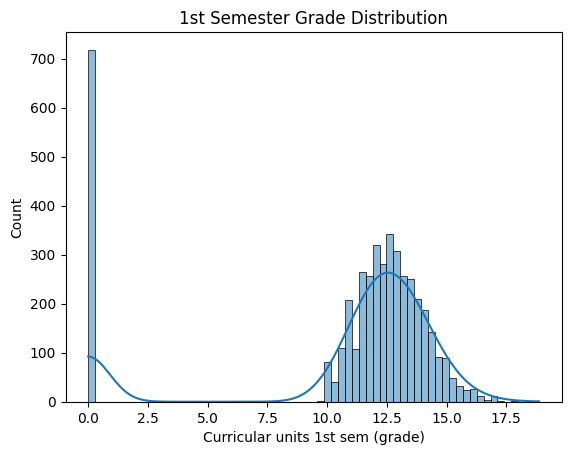

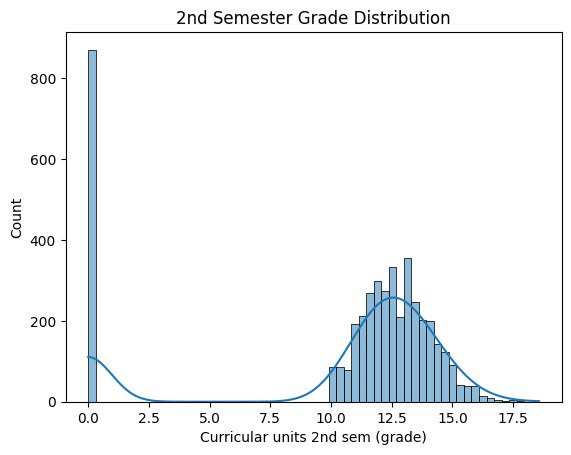

In [135]:
sns.histplot(df['Curricular units 1st sem (grade)'], kde=True)
plt.title("1st Semester Grade Distribution")
plt.show()

sns.histplot(df['Curricular units 2nd sem (grade)'], kde=True)
plt.title("2nd Semester Grade Distribution")
plt.show()

ABSENCES vs TARGET

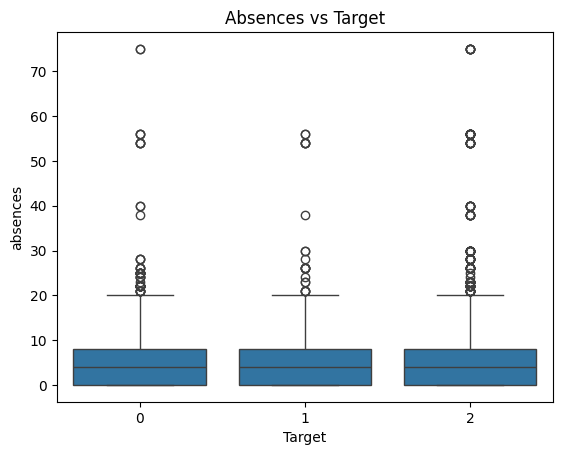

In [136]:
sns.boxplot(x='Target', y='absences', data=df)
plt.title("Absences vs Target")
plt.show()

USE ONLY FINAL FEATURES

In [137]:
X_final = df[final_features_Union]
y = df['Target']

TRAIN-TEST SPLIT

In [138]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

FEATURE SCALING

In [139]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

SMOTE

In [140]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled, y_train
)

Check after SMOTE

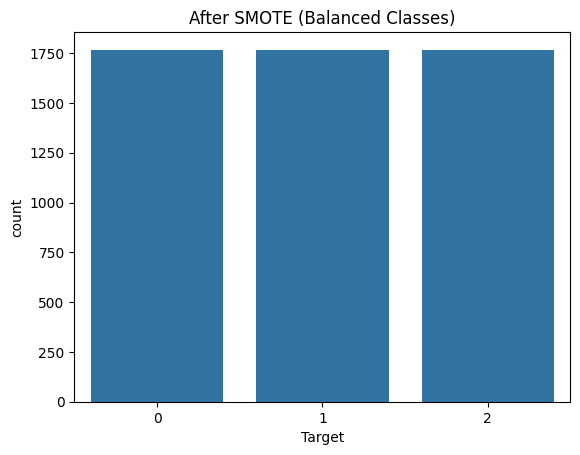

In [141]:
import seaborn as sns
sns.countplot(x=y_train_resampled)
plt.title("After SMOTE (Balanced Classes)")
plt.show()

COMMON EVALUATION FUNCTION

In [142]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []  # keep this outside

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{name} Results:")
    print("Accuracy:", acc)

    # STORE results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# **1. KNN**

In [143]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model("KNN", knn, X_train_resampled, X_test_scaled, y_train_resampled, y_test)


KNN Results:
Accuracy: 0.6293785310734463


# **2. DECISION TREE**

In [144]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
evaluate_model("Decision Tree", dt, X_train_resampled, X_test_scaled, y_train_resampled, y_test)


Decision Tree Results:
Accuracy: 0.6361581920903955


# **3. NAIVE BAYES**

In [145]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
evaluate_model("Naive Bayes", nb, X_train_resampled, X_test_scaled, y_train_resampled, y_test)


Naive Bayes Results:
Accuracy: 0.6734463276836158


# **4. RANDOM FOREST**

In [146]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model("Random Forest", rf, X_train_resampled, X_test_scaled, y_train_resampled, y_test)


Random Forest Results:
Accuracy: 0.7570621468926554


# **5. LOGISTIC REGRESSION**

In [147]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
evaluate_model("Logistic Regression", lr, X_train_resampled, X_test_scaled, y_train_resampled, y_test)


Logistic Regression Results:
Accuracy: 0.7186440677966102


# **6. XGBOOST**

In [148]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
evaluate_model("XGBoost", xgb, X_train_resampled, X_test_scaled, y_train_resampled, y_test)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:31:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Results:
Accuracy: 0.7638418079096045


# **7. NEURAL NETWORK**

In [149]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300, random_state=42)
evaluate_model("Neural Network (MLP)", mlp, X_train_resampled, X_test_scaled, y_train_resampled, y_test)


Neural Network (MLP) Results:
Accuracy: 0.6824858757062147


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


# **8. GRADIENT BOOSTING MODEL**

In [150]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=150,     # number of trees
    learning_rate=0.1,    # step size
    max_depth=3,          # tree depth
    random_state=42
)

evaluate_model(
    "Gradient Boosting (Tuned)",
    gb,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)


Gradient Boosting (Tuned) Results:
Accuracy: 0.7491525423728813


# **9. SVM**

In [151]:
from sklearn.svm import SVC

svm = SVC(probability=True)
evaluate_model("SVM", svm, X_train_resampled, X_test_scaled, y_train_resampled, y_test)


SVM Results:
Accuracy: 0.7242937853107345


# **10. LightGBM**

In [152]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier()
evaluate_model("LightGBM", lgbm, X_train_resampled, X_test_scaled, y_train_resampled, y_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000853 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6192
[LightGBM] [Info] Number of data points in the train set: 5301, number of used features: 29
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

LightGBM Results:
Accuracy: 0.751412429378531


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [153]:
for res in results:
    print(f"Model: {res['Model']}")
    print(f"Accuracy: {res['Accuracy']:.4f}")
    print(f"Precision: {res['Precision']:.4f}")
    print(f"Recall: {res['Recall']:.4f}")
    print(f"F1 Score: {res['F1 Score']:.4f}")
    print("-" * 40)

Model: KNN
Accuracy: 0.6294
Precision: 0.6913
Recall: 0.6294
F1 Score: 0.6472
----------------------------------------
Model: Decision Tree
Accuracy: 0.6362
Precision: 0.6621
Recall: 0.6362
F1 Score: 0.6467
----------------------------------------
Model: Naive Bayes
Accuracy: 0.6734
Precision: 0.6998
Recall: 0.6734
F1 Score: 0.6837
----------------------------------------
Model: Random Forest
Accuracy: 0.7571
Precision: 0.7533
Recall: 0.7571
F1 Score: 0.7533
----------------------------------------
Model: Logistic Regression
Accuracy: 0.7186
Precision: 0.7638
Recall: 0.7186
F1 Score: 0.7332
----------------------------------------
Model: XGBoost
Accuracy: 0.7638
Precision: 0.7586
Recall: 0.7638
F1 Score: 0.7603
----------------------------------------
Model: Neural Network (MLP)
Accuracy: 0.6825
Precision: 0.6983
Recall: 0.6825
F1 Score: 0.6893
----------------------------------------
Model: Gradient Boosting (Tuned)
Accuracy: 0.7492
Precision: 0.7552
Recall: 0.7492
F1 Score: 0.7511
--

**RESULTS TABLE**

In [154]:
results_df = pd.DataFrame(results)

# Sort by F1 Score (best metric for your case)
results_df = results_df.sort_values(by="F1 Score", ascending=False)

# Reset index for clean display
results_df.reset_index(drop=True, inplace=True)

print(results_df)

                       Model  Accuracy  Precision    Recall  F1 Score
0                    XGBoost  0.763842   0.758640  0.763842  0.760327
1              Random Forest  0.757062   0.753267  0.757062  0.753330
2  Gradient Boosting (Tuned)  0.749153   0.755152  0.749153  0.751119
3                   LightGBM  0.751412   0.747122  0.751412  0.748413
4                        SVM  0.724294   0.759167  0.724294  0.736107
5        Logistic Regression  0.718644   0.763799  0.718644  0.733206
6       Neural Network (MLP)  0.682486   0.698264  0.682486  0.689345
7                Naive Bayes  0.673446   0.699786  0.673446  0.683693
8                        KNN  0.629379   0.691350  0.629379  0.647184
9              Decision Tree  0.636158   0.662079  0.636158  0.646747


In [155]:
top_models = results_df["Model"].head(3).tolist()

print("Top 3 Models:", top_models)

Top 3 Models: ['XGBoost', 'Random Forest', 'Gradient Boosting (Tuned)']


In [156]:
top_2_models = results_df["Model"].head(2).tolist()

print("Top 2 Models:", top_2_models)

Top 2 Models: ['XGBoost', 'Random Forest']


In [157]:
print(results_df.head(5))

                       Model  Accuracy  Precision    Recall  F1 Score
0                    XGBoost  0.763842   0.758640  0.763842  0.760327
1              Random Forest  0.757062   0.753267  0.757062  0.753330
2  Gradient Boosting (Tuned)  0.749153   0.755152  0.749153  0.751119
3                   LightGBM  0.751412   0.747122  0.751412  0.748413
4                        SVM  0.724294   0.759167  0.724294  0.736107


ENSEMBLE WITH TOP 2 MODELS

In [158]:
from sklearn.ensemble import VotingClassifier

voting_2_updated = VotingClassifier(
    estimators=[
        ('lgbm', lgbm),
        ('rf', rf)
    ],
    voting='soft'
)

evaluate_model(
    "Voting (LGBM + RF)",
    voting_2_updated,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000894 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6192
[LightGBM] [Info] Number of data points in the train set: 5301, number of used features: 29
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

Voting (LGBM + RF) Results:
Accuracy: 0.7615819209039548


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ENSEMBLE WITH TOP 3 MODELS

In [159]:
voting_3_updated = VotingClassifier(
    estimators=[
        ('lgbm', lgbm),
        ('rf', rf),
        ('gb', gb)
    ],
    voting='soft'
)

evaluate_model(
    "Voting (LGBM + RF + GB)",
    voting_3_updated,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6192
[LightGBM] [Info] Number of data points in the train set: 5301, number of used features: 29
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

Voting (LGBM + RF + GB) Results:
Accuracy: 0.7638418079096045


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


STACKING WITH TOP 2 MODELS

In [160]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_2_updated = StackingClassifier(
    estimators=[
        ('lgbm', lgbm),
        ('rf', rf)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

evaluate_model(
    "Stacking (LGBM + RF)",
    stack_2_updated,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000919 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6192
[LightGBM] [Info] Number of data points in the train set: 5301, number of used features: 29
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000704 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6198
[LightGBM] [Info] Number of data points in the train set: 4240, number of used features: 29
[LightGBM] [Info] Start training from score -1.098141
[LightGBM] [Info] Start training from score -1.098848
[LightGBM] [Info] Start tr

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000709 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6178
[LightGBM] [Info] Number of data points in the train set: 4241, number of used features: 29
[LightGBM] [Info] Start training from score -1.098377
[LightGBM] [Info] Start training from score -1.098377
[LightGBM] [Info] Start training from score -1.099084


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001694 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6130
[LightGBM] [Info] Number of data points in the train set: 4241, number of used features: 29
[LightGBM] [Info] Start training from score -1.099084
[LightGBM] [Info] Start training from score -1.098377
[LightGBM] [Info] Start training from score -1.098377


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002371 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6047
[LightGBM] [Info] Number of data points in the train set: 4241, number of used features: 29
[LightGBM] [Info] Start training from score -1.098377
[LightGBM] [Info] Start training from score -1.099084
[LightGBM] [Info] Start training from score -1.098377


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Stacking (LGBM + RF) Results:
Accuracy: 0.7570621468926554


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


STACKING WITH TOP 3 MODELS

In [161]:
stack_3_updated = StackingClassifier(
    estimators=[
        ('lgbm', lgbm),
        ('rf', rf),
        ('gb', gb)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)

evaluate_model(
    "Stacking (LGBM + RF + GB)",
    stack_3_updated,
    X_train_resampled,
    X_test_scaled,
    y_train_resampled,
    y_test
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002249 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6192
[LightGBM] [Info] Number of data points in the train set: 5301, number of used features: 29
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000746 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6198
[LightGBM] [Info] Number of data points in the train set: 4240, number of used features: 29
[LightGBM] [Info] Start training from score -1.098141
[LightGBM] [Info] Start training from score -1.098848
[LightGBM] [Info] Start training from score -1.098848


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000706 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6178
[LightGBM] [Info] Number of data points in the train set: 4241, number of used features: 29
[LightGBM] [Info] Start training from score -1.098377
[LightGBM] [Info] Start training from score -1.098377
[LightGBM] [Info] Start training from score -1.099084


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000699 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6130
[LightGBM] [Info] Number of data points in the train set: 4241, number of used features: 29
[LightGBM] [Info] Start training from score -1.099084
[LightGBM] [Info] Start training from score -1.098377
[LightGBM] [Info] Start training from score -1.098377


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000720 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6047
[LightGBM] [Info] Number of data points in the train set: 4241, number of used features: 29
[LightGBM] [Info] Start training from score -1.098377
[LightGBM] [Info] Start training from score -1.099084
[LightGBM] [Info] Start training from score -1.098377


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Stacking (LGBM + RF + GB) Results:
Accuracy: 0.7536723163841808


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [162]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Score", ascending=False)
results_df.reset_index(drop=True, inplace=True)

print(results_df)

                        Model  Accuracy  Precision    Recall  F1 Score
0     Voting (LGBM + RF + GB)  0.763842   0.764273  0.763842  0.762803
1                     XGBoost  0.763842   0.758640  0.763842  0.760327
2          Voting (LGBM + RF)  0.761582   0.759765  0.761582  0.759355
3        Stacking (LGBM + RF)  0.757062   0.753553  0.757062  0.755119
4               Random Forest  0.757062   0.753267  0.757062  0.753330
5   Gradient Boosting (Tuned)  0.749153   0.755152  0.749153  0.751119
6   Stacking (LGBM + RF + GB)  0.753672   0.746864  0.753672  0.749756
7                    LightGBM  0.751412   0.747122  0.751412  0.748413
8                         SVM  0.724294   0.759167  0.724294  0.736107
9         Logistic Regression  0.718644   0.763799  0.718644  0.733206
10       Neural Network (MLP)  0.682486   0.698264  0.682486  0.689345
11                Naive Bayes  0.673446   0.699786  0.673446  0.683693
12                        KNN  0.629379   0.691350  0.629379  0.647184
13    